In [ ]:
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()
X = data.data  # Features
y = data.target  # Labels

print(f"Shape: {X.shape}")
print(f"Features: {data.feature_names}")
print(f"Classes: {data.target_names}")

Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [ ]:
from sklearn.datasets import load_wine

# Load dataset
data = load_wine()
X = data.data  # Features
y = data.target  # Labels

print(f"Shape: {X.shape}")
print(f"Features: {data.feature_names}")
print(f"Classes: {data.target_names}")

Shape: (178, 13)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: ['class_0' 'class_1' 'class_2']


In [3]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
data = load_wine()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                          target_names=data.target_names))

Accuracy: 1.000

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



/tmp/ipython-input-4199432000.py:31: RuntimeWarning: overflow encountered in square
  cost = (1 / (2 * m)) * np.sum(errors ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-4199432000.py:43: RuntimeWarning: invalid value encountered in scalar subtract
  self.theta1 -= self.learning_rate * gradient_theta1


Learned Parameters:
  Intercept (θ₀): nan
  Slope (θ₁): nan

Predictions vs Actual:
  X=1000: Predicted=nan, Actual=150000
  X=1500: Predicted=nan, Actual=200000
  X=2000: Predicted=nan, Actual=280000
  X=2500: Predicted=nan, Actual=350000
  X=3000: Predicted=nan, Actual=420000


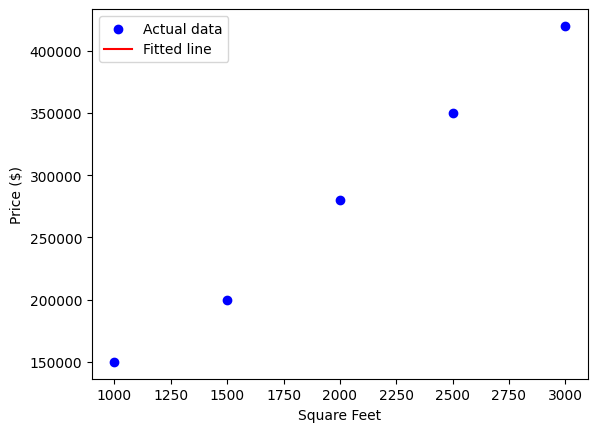

In [5]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionFromScratch:
    """Linear Regression implemented from scratch using NumPy."""

    def __init__(self, learning_rate=0.01, iterations=1000):
        # learning_rate: controls how big each step is during training
        # iterations: how many times we update our parameters
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.theta0 = 0  # intercept (y-intercept of the line)
        self.theta1 = 0  # slope (steepness of the line)
        self.cost_history = []  # track cost over iterations

    def fit(self, X, y):
        """Train the model on data X and labels y."""
        m = len(X)  # number of training examples

        # Repeat the learning process for specified iterations
        for iteration in range(self.iterations):
            # Step 1: Make predictions using current parameters
            # y_pred = theta0 + theta1 * X
            y_pred = self.theta0 + self.theta1 * X

            # Step 2: Calculate errors (difference between predicted and actual)
            errors = y_pred - y

            # Step 3: Calculate cost (Mean Squared Error)
            # Cost = (1/2m) * sum(errors²)
            cost = (1 / (2 * m)) * np.sum(errors ** 2)
            self.cost_history.append(cost)

            # Step 4: Calculate gradients (direction and magnitude of change)
            # Gradient for theta0 = (1/m) * sum(errors)
            gradient_theta0 = (1 / m) * np.sum(errors)
            # Gradient for theta1 = (1/m) * sum(errors * X)
            gradient_theta1 = (1 / m) * np.sum(errors * X)

            # Step 5: Update parameters using gradients
            # Move in opposite direction of gradient to minimize cost
            self.theta0 -= self.learning_rate * gradient_theta0
            self.theta1 -= self.learning_rate * gradient_theta1

        return self

    def predict(self, X):
        """Make predictions on new data."""
        # Use learned parameters to predict: y = theta0 + theta1 * X
        return self.theta0 + self.theta1 * X

    def get_parameters(self):
        """Return learned parameters."""
        return {'intercept': self.theta0, 'slope': self.theta1}

# Example usage
if __name__ == '__main__':
    # Sample data: house sizes and prices
    X = np.array([1000, 1500, 2000, 2500, 3000])  # square feet
    y = np.array([150000, 200000, 280000, 350000, 420000])  # prices

    # Create and train model
    model = LinearRegressionFromScratch(learning_rate=0.00001, iterations=1000)
    model.fit(X, y)

    # Make predictions
    predictions = model.predict(X)

    # Print results
    print('Learned Parameters:')
    params = model.get_parameters()
    print(f'  Intercept (θ₀): {params["intercept"]:.2f}')
    print(f'  Slope (θ₁): {params["slope"]:.2f}')
    print(f'\nPredictions vs Actual:')
    for i in range(len(X)):
        print(f'  X={X[i]}: Predicted={predictions[i]:.0f}, Actual={y[i]}')

    # Visualize
    plt.scatter(X, y, color='blue', label='Actual data')
    plt.plot(X, predictions, color='red', label='Fitted line')
    plt.xlabel('Square Feet')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.show()

Intercept: 4000.00
Slope: 138.00

Predictions:
  X=1000: Predicted=142000, Actual=150000
  X=1500: Predicted=211000, Actual=200000
  X=2000: Predicted=280000, Actual=280000
  X=2500: Predicted=349000, Actual=350000
  X=3000: Predicted=418000, Actual=420000

Model Evaluation:
  MSE: 38000000.00
  RMSE: 6164.41
  R² Score: 0.9960


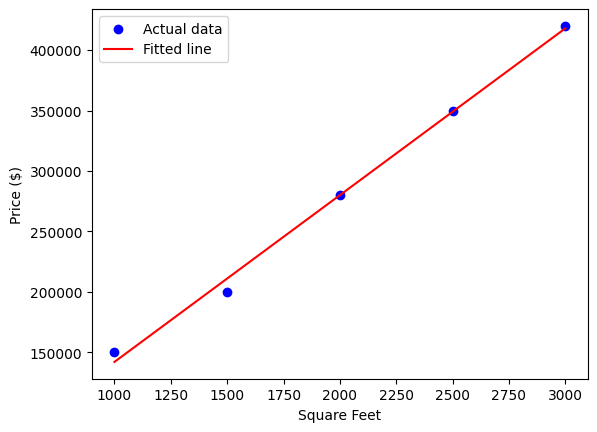

In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Sample data
X = np.array([1000, 1500, 2000, 2500, 3000]).reshape(-1, 1)  # reshape for sklearn
y = np.array([150000, 200000, 280000, 350000, 420000])

# Create and train model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Extract parameters
intercept = model.intercept_
slope = model.coef_[0]

print(f'Intercept: {intercept:.2f}')
print(f'Slope: {slope:.2f}')
print(f'\nPredictions:')
for i in range(len(X)):
    print(f'  X={X[i][0]}: Predicted={y_pred[i]:.0f}, Actual={y[i]}')

# Evaluate model
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print(f'\nModel Evaluation:')
print(f'  MSE: {mse:.2f}')
print(f'  RMSE: {rmse:.2f}')
print(f'  R² Score: {r2:.4f}')

# Visualize
plt.scatter(X, y, color='blue', label='Actual data')
plt.plot(X, y_pred, color='red', label='Fitted line')
plt.xlabel('Square Feet')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [7]:
import numpy as np

class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.theta = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        m, n = X.shape
        X = np.c_[np.ones(m), X]
        self.theta = np.zeros(n + 1)
        for _ in range(self.iterations):
            h = self.sigmoid(X @ self.theta)
            gradient = (1/m) * X.T @ (h - y)
            self.theta -= self.lr * gradient
        return self

    def predict(self, X):
        m = X.shape[0]
        X = np.c_[np.ones(m), X]
        return (self.sigmoid(X @ self.theta) >= 0.5).astype(int)

In [8]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X, y)
preds = model.predict(X)

In [9]:
import numpy as np
from collections import Counter

class KNNFromScratch:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Store training data"""
        self.X_train = X
        self.y_train = y
        return self

    def euclidean_distance(self, x1, x2):
        """Calculate Euclidean distance"""
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict(self, X):
        """Predict class for each test point"""
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)

    def _predict_single(self, x):
        """Predict class for a single point"""
        # Compute distances to all training points
        distances = [self.euclidean_distance(x, x_train) for x_train in self.X_train]

        # Get indices of k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]

        # Get labels of k nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Return most common label
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

# Example
X_train = np.array([[1.4, 0.2], [1.3, 0.3], [4.5, 1.5], [4.7, 1.4], [6.0, 2.5]])
y_train = np.array([0, 0, 1, 1, 2])
X_test = np.array([[4.6, 1.4]])

model = KNNFromScratch(k=3)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(f'Prediction: {predictions[0]}')

Prediction: 1


In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

X_train = np.array([[1.4, 0.2], [1.3, 0.3], [4.5, 1.5], [4.7, 1.4], [6.0, 2.5]])
y_train = np.array([0, 0, 1, 1, 2])
X_test = np.array([[4.6, 1.4], [1.5, 0.4]])

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print(f'Predictions: {y_pred}')
print(f'Probabilities:\n{y_proba}')

Predictions: [1 0]
Probabilities:
[[0.         0.66666667 0.33333333]
 [0.66666667 0.33333333 0.        ]]


Converged at iteration 2

Final Inertia: 286.18

Centroids:
  Cluster 0: [7.90454712 2.14006205]
  Cluster 1: [1.86432437 1.9279826 ]
  Cluster 2: [5.12894675 8.00084575]


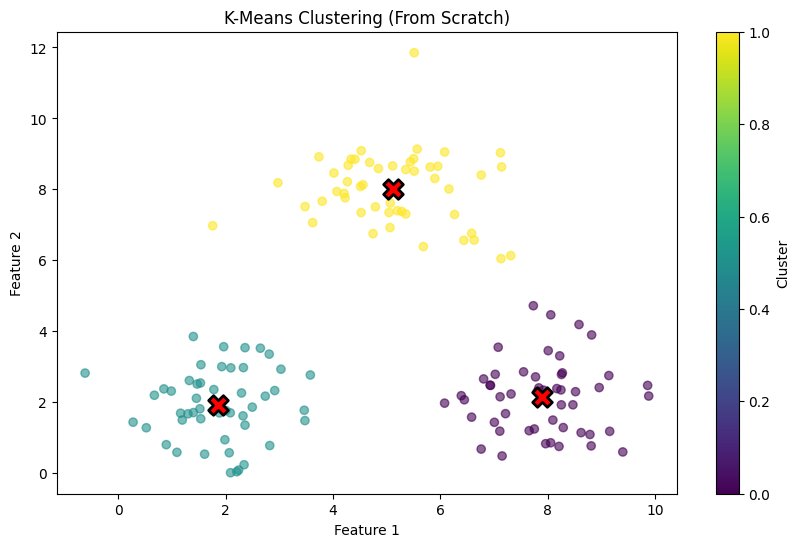

In [11]:
import numpy as np
import matplotlib.pyplot as plt

class KMeansFromScratch:
    """K-Means clustering implemented from scratch."""

    def __init__(self, n_clusters=3, max_iters=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.inertia = None

    def fit(self, X):
        """Fit K-Means to data X."""
        np.random.seed(self.random_state)

        # Step 1: Initialize centroids randomly
        # Pick K random points from data as initial centroids
        random_indices = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[random_indices].copy()

        # Iterate until convergence or max iterations
        for iteration in range(self.max_iters):
            # Step 2: Assignment - assign each point to nearest centroid
            self.labels = self._assign_clusters(X)

            # Step 3: Update - recalculate centroids
            new_centroids = self._update_centroids(X)

            # Check for convergence (centroids don't change)
            if np.allclose(self.centroids, new_centroids):
                print(f'Converged at iteration {iteration + 1}')
                break

            self.centroids = new_centroids

        # Calculate final inertia (within-cluster sum of squares)
        self.inertia = self._calculate_inertia(X)

        return self

    def _assign_clusters(self, X):
        """Assign each point to the nearest centroid."""
        # Calculate distance from each point to each centroid
        distances = np.zeros((len(X), self.n_clusters))

        for k in range(self.n_clusters):
            # Euclidean distance: sqrt(sum((x - centroid)^2))
            distances[:, k] = np.sqrt(np.sum((X - self.centroids[k]) ** 2, axis=1))

        # Assign to nearest centroid (minimum distance)
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X):
        """Update centroids as mean of assigned points."""
        new_centroids = np.zeros((self.n_clusters, X.shape[1]))

        for k in range(self.n_clusters):
            # Find all points assigned to cluster k
            cluster_points = X[self.labels == k]

            if len(cluster_points) > 0:
                # Centroid = mean of all points in cluster
                new_centroids[k] = cluster_points.mean(axis=0)
            else:
                # If cluster is empty, keep old centroid
                new_centroids[k] = self.centroids[k]

        return new_centroids

    def _calculate_inertia(self, X):
        """Calculate within-cluster sum of squares."""
        inertia = 0
        for k in range(self.n_clusters):
            cluster_points = X[self.labels == k]
            if len(cluster_points) > 0:
                # Sum of squared distances to centroid
                inertia += np.sum((cluster_points - self.centroids[k]) ** 2)
        return inertia

    def predict(self, X):
        """Predict cluster for new data."""
        return self._assign_clusters(X)

# Example usage
if __name__ == '__main__':
    # Generate sample data: 3 clusters
    np.random.seed(42)
    cluster1 = np.random.randn(50, 2) + [2, 2]
    cluster2 = np.random.randn(50, 2) + [8, 2]
    cluster3 = np.random.randn(50, 2) + [5, 8]
    X = np.vstack([cluster1, cluster2, cluster3])

    # Fit K-Means
    kmeans = KMeansFromScratch(n_clusters=3, max_iters=100)
    kmeans.fit(X)

    # Results
    print(f'\nFinal Inertia: {kmeans.inertia:.2f}')
    print(f'\nCentroids:')
    for i, centroid in enumerate(kmeans.centroids):
        print(f'  Cluster {i}: {centroid}')

    # Visualize
    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels, cmap='viridis', alpha=0.6)
    plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
                c='red', marker='X', s=200, edgecolors='black', linewidths=2)
    plt.title('K-Means Clustering (From Scratch)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar(label='Cluster')
    plt.show()

Cluster Assignments:
    Income  Spending  Cluster
0       15        39        2
1       16        81        0
2       17         6        2
3       18        77        0
4       19        40        2
5       42        76        0
6       43        94        0
7       44        72        0
8       54        35        1
9       55        92        0
10      70         5        1
11      71        14        1
12      72         8        1
13      88        39        1
14      89        48        1

Centroids (original scale):
  Cluster 0: Income=$36.3k, Spending=82.0
  Cluster 1: Income=$74.0k, Spending=24.8
  Cluster 2: Income=$17.0k, Spending=28.3

Inertia: 6.15

Clustering Quality:
  Silhouette Score: 0.549 (higher is better, range: -1 to 1)
  Davies-Bouldin Index: 0.557 (lower is better)


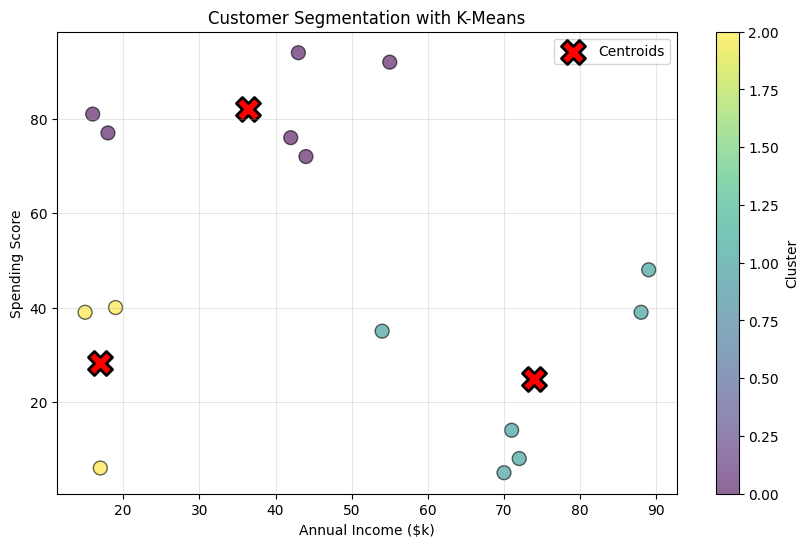

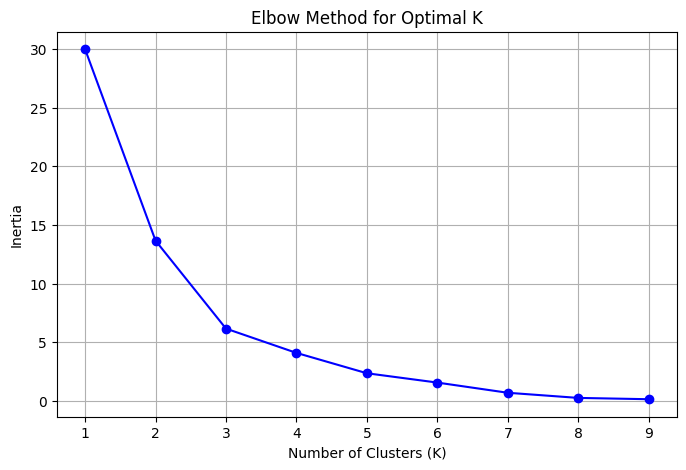

In [12]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Sample data: Customer segmentation
data = {
    'Income': [15, 16, 17, 18, 19, 42, 43, 44, 54, 55, 70, 71, 72, 88, 89],
    'Spending': [39, 81, 6, 77, 40, 76, 94, 72, 35, 92, 5, 14, 8, 39, 48]
}
df = pd.DataFrame(data)
X = df.values

# Optional: Standardize features (recommended)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create and fit K-Means model
kmeans = KMeans(
    n_clusters=3,           # Number of clusters
    init='k-means++',       # Smart initialization
    n_init=10,              # Number of times to run with different seeds
    max_iter=300,           # Maximum iterations
    random_state=42         # For reproducibility
)

kmeans.fit(X_scaled)

# Get results
labels = kmeans.labels_
centroids = scaler.inverse_transform(kmeans.cluster_centers_)  # Back to original scale
inertia = kmeans.inertia_

# Add cluster labels to dataframe
df['Cluster'] = labels

print('Cluster Assignments:')
print(df)
print(f'\nCentroids (original scale):')
for i, centroid in enumerate(centroids):
    print(f'  Cluster {i}: Income=${centroid[0]:.1f}k, Spending={centroid[1]:.1f}')
print(f'\nInertia: {inertia:.2f}')

# Evaluate clustering quality
silhouette = silhouette_score(X_scaled, labels)
davies_bouldin = davies_bouldin_score(X_scaled, labels)

print(f'\nClustering Quality:')
print(f'  Silhouette Score: {silhouette:.3f} (higher is better, range: -1 to 1)')
print(f'  Davies-Bouldin Index: {davies_bouldin:.3f} (lower is better)')

# Visualize clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Income'], df['Spending'], c=labels,
                     cmap='viridis', s=100, alpha=0.6, edgecolors='black')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X',
           s=300, edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('Annual Income ($k)')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation with K-Means')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Elbow method to find optimal K
inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

In [13]:
import numpy as np

class GaussianNaiveBayes:
    """Gaussian Naive Bayes classifier from scratch."""

    def __init__(self):
        self.classes = None
        self.class_priors = {}  # P(C)
        self.means = {}         # μ for each feature per class
        self.variances = {}     # σ² for each feature per class

    def fit(self, X, y):
        """Train the Naive Bayes classifier."""
        self.classes = np.unique(y)
        n_samples = len(y)

        # Calculate priors and parameters for each class
        for c in self.classes:
            # Get all samples belonging to class c
            X_c = X[y == c]

            # Prior: P(C) = count(C) / total_samples
            self.class_priors[c] = len(X_c) / n_samples

            # For each feature, calculate mean and variance
            # Assumes features follow Gaussian distribution
            self.means[c] = X_c.mean(axis=0)
            self.variances[c] = X_c.var(axis=0)

        return self

    def _calculate_likelihood(self, x, mean, var):
        """Calculate Gaussian probability density."""
        # Gaussian PDF: (1/√(2πσ²)) * exp(-(x-μ)²/(2σ²))
        eps = 1e-6  # Small constant to avoid division by zero
        coeff = 1.0 / np.sqrt(2 * np.pi * var + eps)
        exponent = np.exp(-((x - mean) ** 2) / (2 * var + eps))
        return coeff * exponent

    def _calculate_class_probability(self, x, c):
        """Calculate P(C|X) ∝ P(C) * P(X|C)."""
        # Start with prior probability
        log_prob = np.log(self.class_priors[c])

        # Multiply by likelihood of each feature (use log for stability)
        # P(X|C) = P(x₁|C) * P(x₂|C) * ... * P(xₙ|C)
        for i in range(len(x)):
            likelihood = self._calculate_likelihood(
                x[i],
                self.means[c][i],
                self.variances[c][i]
            )
            log_prob += np.log(likelihood + 1e-10)  # Add small constant to avoid log(0)

        return log_prob

    def predict(self, X):
        """Predict class for each sample."""
        predictions = []

        for x in X:
            # Calculate probability for each class
            class_probs = {}
            for c in self.classes:
                class_probs[c] = self._calculate_class_probability(x, c)

            # Choose class with maximum probability
            predicted_class = max(class_probs, key=class_probs.get)
            predictions.append(predicted_class)

        return np.array(predictions)

    def predict_proba(self, X):
        """Predict probability for each class."""
        probabilities = []

        for x in X:
            # Calculate log probability for each class
            log_probs = []
            for c in self.classes:
                log_probs.append(self._calculate_class_probability(x, c))

            # Convert log probabilities to probabilities (softmax)
            log_probs = np.array(log_probs)
            # Subtract max for numerical stability
            log_probs = log_probs - np.max(log_probs)
            probs = np.exp(log_probs)
            probs = probs / np.sum(probs)  # Normalize

            probabilities.append(probs)

        return np.array(probabilities)

# Example usage
if __name__ == '__main__':
    # Generate sample data: 2 classes with different means
    np.random.seed(42)

    # Class 0: mean=[2, 2]
    X_class0 = np.random.randn(50, 2) + [2, 2]
    y_class0 = np.zeros(50)

    # Class 1: mean=[5, 5]
    X_class1 = np.random.randn(50, 2) + [5, 5]
    y_class1 = np.ones(50)

    # Combine data
    X = np.vstack([X_class0, X_class1])
    y = np.hstack([y_class0, y_class1])

    # Train model
    nb = GaussianNaiveBayes()
    nb.fit(X, y)

    # Test predictions
    test_samples = np.array([[2, 2], [5, 5], [3.5, 3.5]])
    predictions = nb.predict(test_samples)
    probabilities = nb.predict_proba(test_samples)

    print('Predictions:')
    for i, (sample, pred, prob) in enumerate(zip(test_samples, predictions, probabilities)):
        print(f'  Sample {sample}: Class {int(pred)}, Probabilities: {prob}')

    print(f'\nClass Priors: {nb.class_priors}')
    print(f'Class 0 means: {nb.means[0.0]}')
    print(f'Class 1 means: {nb.means[1.0]}')

Predictions:
  Sample [2. 2.]: Class 0, Probabilities: [9.99971569e-01 2.84309128e-05]
  Sample [5. 5.]: Class 1, Probabilities: [5.70120573e-06 9.99994299e-01]
  Sample [3.5 3.5]: Class 1, Probabilities: [0.3652783 0.6347217]

Class Priors: {np.float64(0.0): 0.5, np.float64(1.0): 0.5}
Class 0 means: [1.86432437 1.9279826 ]
Class 1 means: [4.90454712 5.14006205]


Accuracy: 0.978

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45


Sample Predictions:
  True: versicolor, Predicted: versicolor, Probabilities: [4.15880005e-88 9.95527834e-01 4.47216606e-03]
  True: setosa, Predicted: setosa, Probabilities: [1.00000000e+00 1.31031235e-13 2.21772205e-20]
  True: virginica, Predicted: virginica, Probabilities: [9.83170191e-285 2.70138564e-012 1.00000000e+000]
  True: versicolor, Predicted: versicolor, Probabilities: [9.54745274e-92 9.74861431e-01 2.51385686e-02]
  True: versicolor, Predicted: versicolor, Probabilities: [1.0867956e-103 8.3191070e-001 1.6808930e-001]


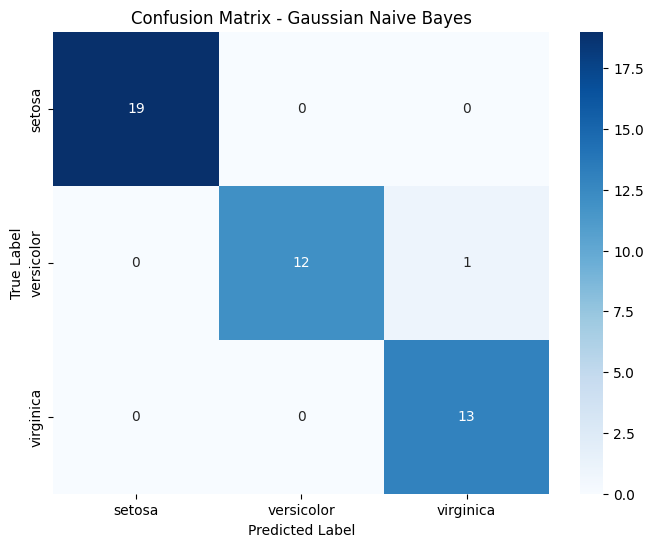


Text Classification Example:
  Email: "free prize winner"
  Prediction: Spam
  Probabilities: Not Spam=0.040, Spam=0.960

Binary Features Example:
  Features: [1 1 1]
  Prediction: Class 1


In [14]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

# Load sample data (Iris dataset)
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create and train Gaussian Naive Bayes
# Use GaussianNB for continuous features
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Make predictions
y_pred = gnb.predict(X_test)
y_proba = gnb.predict_proba(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.3f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Show some predictions with probabilities
print(f'\nSample Predictions:')
for i in range(5):
    print(f'  True: {iris.target_names[y_test[i]]}, '
          f'Predicted: {iris.target_names[y_pred[i]]}, '
          f'Probabilities: {y_proba[i]}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Example: Text Classification with Multinomial Naive Bayes
from sklearn.feature_extraction.text import CountVectorizer

# Sample text data
texts = [
    'free money winner',
    'hello friend meeting',
    'win free prize now',
    'lunch tomorrow schedule',
    'congratulations winner prize',
    'project deadline reminder'
]
labels = [1, 0, 1, 0, 1, 0]  # 1=spam, 0=not spam

# Convert text to word counts
vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(texts)

# Train Multinomial Naive Bayes (for count data)
mnb = MultinomialNB(alpha=1.0)  # alpha=1.0 is Laplace smoothing
mnb.fit(X_text, labels)

# Test on new email
test_email = ['free prize winner']
test_vector = vectorizer.transform(test_email)
prediction = mnb.predict(test_vector)
proba = mnb.predict_proba(test_vector)

print(f'\nText Classification Example:')
print(f'  Email: "{test_email[0]}"')
print(f'  Prediction: {"Spam" if prediction[0] == 1 else "Not Spam"}')
print(f'  Probabilities: Not Spam={proba[0][0]:.3f}, Spam={proba[0][1]:.3f}')

# Example: Binary Features with Bernoulli Naive Bayes
X_binary = np.array([
    [1, 1, 0],  # has feature 1 and 2
    [0, 1, 1],  # has feature 2 and 3
    [1, 0, 1],  # has feature 1 and 3
    [0, 0, 1],  # has only feature 3
])
y_binary = np.array([1, 0, 1, 0])

bnb = BernoulliNB(alpha=1.0)
bnb.fit(X_binary, y_binary)

test_binary = np.array([[1, 1, 1]])
pred_binary = bnb.predict(test_binary)
print(f'\nBinary Features Example:')
print(f'  Features: {test_binary[0]}')
print(f'  Prediction: Class {pred_binary[0]}')

In [15]:
import numpy as np
from collections import Counter

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # Feature index to split on
        self.threshold = threshold  # Threshold value for split
        self.left = left           # Left child node
        self.right = right         # Right child node
        self.value = value         # Prediction value (for leaf nodes)

class DecisionTreeFromScratch:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def gini_impurity(self, y):
        """Calculate Gini impurity"""
        counter = Counter(y)
        impurity = 1.0
        for count in counter.values():
            prob = count / len(y)
            impurity -= prob ** 2
        return impurity

    def split(self, X, y, feature, threshold):
        """Split dataset based on feature and threshold"""
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        return X[left_mask], X[right_mask], y[left_mask], y[right_mask]

    def best_split(self, X, y):
        """Find best feature and threshold to split on"""
        best_gain = -1
        best_feature = None
        best_threshold = None

        parent_impurity = self.gini_impurity(y)
        n_samples = len(y)

        # Try each feature
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])

            # Try each threshold
            for threshold in thresholds:
                X_left, X_right, y_left, y_right = self.split(X, y, feature, threshold)

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                # Calculate weighted impurity
                n_left, n_right = len(y_left), len(y_right)
                weighted_impurity = (n_left/n_samples) * self.gini_impurity(y_left) + \
                                   (n_right/n_samples) * self.gini_impurity(y_right)

                # Calculate information gain
                gain = parent_impurity - weighted_impurity

                # Calculate information gain
                gain = parent_impurity - weighted_impurity

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def build_tree(self, X, y, depth=0):
        """Recursively build the decision tree"""
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        # Stopping criteria
        if depth >= self.max_depth or n_samples < self.min_samples_split or n_classes == 1:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)

        # Find best split
        feature, threshold = self.best_split(X, y)

        if feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)

        # Split and recurse
        X_left, X_right, y_left, y_right = self.split(X, y, feature, threshold)
        left_child = self.build_tree(X_left, y_left, depth + 1)
        right_child = self.build_tree(X_right, y_right, depth + 1)

        return Node(feature=feature, threshold=threshold, left=left_child, right=right_child)

    def fit(self, X, y):
        """Train the decision tree"""
        self.root = self.build_tree(X, y)
        return self

    def predict_single(self, x, node):
        """Predict single sample"""
        if node.value is not None:
            return node.value

        if x[node.feature] <= node.threshold:
            return self.predict_single(x, node.left)
        else:
            return self.predict_single(x, node.right)

    def predict(self, X):
        """Predict multiple samples"""
        return np.array([self.predict_single(x, self.root) for x in X])

# Example
X = np.array([[2.5, 1], [3.5, 2], [1.5, 1], [4.5, 3], [2, 2]])
y = np.array([0, 0, 1, 0, 1])

model = DecisionTreeFromScratch(max_depth=3)
model.fit(X, y)
predictions = model.predict(X)
print(f'Predictions: {predictions}')
print(f'Actual: {y}')

Predictions: [0 0 1 0 1]
Actual: [0 0 1 0 1]


Accuracy: 1.00
Tree Depth: 1
Number of Leaves: 2
Feature Importance: [1. 0.]


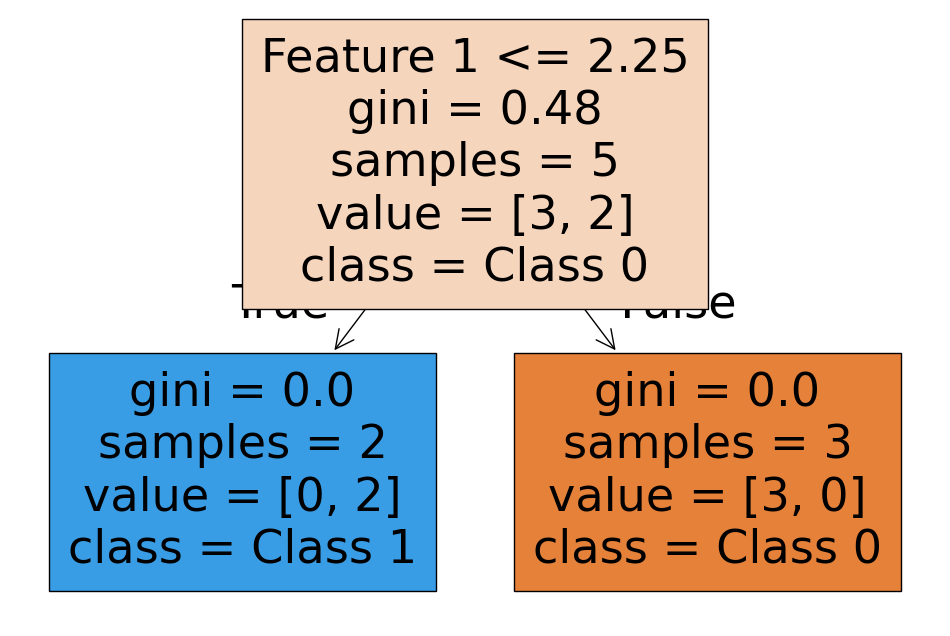

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

X = np.array([[2.5, 1], [3.5, 2], [1.5, 1], [4.5, 3], [2, 2]])
y = np.array([0, 0, 1, 0, 1])

# Create and train model
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

print(f'Accuracy: {accuracy_score(y, y_pred):.2f}')
print(f'Tree Depth: {model.get_depth()}')
print(f'Number of Leaves: {model.get_n_leaves()}')

# Feature importance
print(f'Feature Importance: {model.feature_importances_}')

# Visualize tree
plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, feature_names=['Feature 1', 'Feature 2'], class_names=['Class 0', 'Class 1'])
plt.show()

In [17]:
import numpy as np
class SVM:
    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        for _ in range(1000):
            for i, x_i in enumerate(X):
                if y[i] * (np.dot(x_i, self.w) - self.b) >= 1:
                    self.w -= 0.001 * (2 * 0.01 * self.w)
                else:
                    self.w -= 0.001 * (2 * 0.01 * self.w - np.dot(x_i, y[i]))
                    self.b -= 0.001 * y[i]

In [18]:
from sklearn.svm import SVC
model = SVC(kernel='linear')
model.fit(X, y)

SVC(kernel='linear')

In [19]:
{
  "title": "Sample Input & Output",
  "problem": "Classify handwritten digits (0-9) from 28x28 pixel images",
  "sampleInput": {
    "description": "Flattened 28x28 grayscale image (784 features)",
    "shape": "[784]",
    "example": "Pixel values normalized to [0, 1]"
  },
  "sampleOutput": {
    "description": "Probability distribution over 10 classes",
    "shape": "[10]",
    "example": "[0.01, 0.02, 0.85, 0.03, 0.01, 0.02, 0.01, 0.02, 0.02, 0.01]",
    "interpretation": "The model predicts digit '2' with 85% confidence"
  },
  "walkthrough": "1. Input image is flattened to 784 values\n2. First hidden layer (128 neurons) processes features\n3. Second hidden layer (64 neurons) learns higher-level patterns\n4. Output layer (10 neurons) produces class probabilities\n5. Highest probability indicates predicted digit"
}

{'title': 'Sample Input & Output',
 'problem': 'Classify handwritten digits (0-9) from 28x28 pixel images',
 'sampleInput': {'description': 'Flattened 28x28 grayscale image (784 features)',
  'shape': '[784]',
  'example': 'Pixel values normalized to [0, 1]'},
 'sampleOutput': {'description': 'Probability distribution over 10 classes',
  'shape': '[10]',
  'example': '[0.01, 0.02, 0.85, 0.03, 0.01, 0.02, 0.01, 0.02, 0.02, 0.01]',
  'interpretation': "The model predicts digit '2' with 85% confidence"},
 'walkthrough': '1. Input image is flattened to 784 values\n2. First hidden layer (128 neurons) processes features\n3. Second hidden layer (64 neurons) learns higher-level patterns\n4. Output layer (10 neurons) produces class probabilities\n5. Highest probability indicates predicted digit'}

In [20]:
import numpy as np

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights with small random values
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def relu(self, z):
        """ReLU activation function"""
        return np.maximum(0, z)

    def relu_derivative(self, z):
        """Derivative of ReLU"""
        return (z > 0).astype(float)

    def softmax(self, z):
        """Softmax for output layer"""
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, X):
        """Forward propagation"""
        # Hidden layer
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)

        # Output layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.softmax(self.z2)

        return self.a2

    def backward(self, X, y, learning_rate=0.01):
        """Backpropagation"""
        m = X.shape[0]

        # Output layer gradients
        dz2 = self.a2 - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # Hidden layer gradients
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.relu_derivative(self.z1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X, y, epochs=1000, learning_rate=0.01):
        """Training loop"""
        for epoch in range(epochs):
            # Forward pass
            predictions = self.forward(X)

            # Compute loss
            loss = -np.mean(np.sum(y * np.log(predictions + 1e-8), axis=1))

            # Backward pass
            self.backward(X, y, learning_rate)

            if epoch % 100 == 0:
                print(f'Epoch {epoch}, Loss: {loss:.4f}')

    def predict(self, X):
        """Make predictions"""
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

# Example usage
if __name__ == '__main__':
    # Generate sample data
    np.random.seed(42)
    X = np.random.randn(100, 20)  # 100 samples, 20 features
    y = np.eye(3)[np.random.randint(0, 3, 100)]  # 3 classes, one-hot encoded

    # Create and train network
    nn = NeuralNetwork(input_size=20, hidden_size=10, output_size=3)
    nn.train(X, y, epochs=500, learning_rate=0.1)

    # Make predictions
    predictions = nn.predict(X)
    accuracy = np.mean(predictions == np.argmax(y, axis=1))
    print(f'Training Accuracy: {accuracy:.2%}')

Epoch 0, Loss: 1.0986
Epoch 100, Loss: 1.0812
Epoch 200, Loss: 0.9313
Epoch 300, Loss: 0.6162
Epoch 400, Loss: 0.4107
Training Accuracy: 94.00%


In [21]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

# Generate sample dataset
X, y = make_classification(n_samples=1000, n_features=20,
                          n_informative=15, n_classes=3,
                          random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(20,)),
    layers.Dropout(0.3),  # Regularization
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 classes
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc:.2%}')

# Make predictions
predictions = model.predict(X_test)
print(f'Prediction probabilities shape: {predictions.shape}')
print(f'Sample prediction: {predictions[0]}')
print(f'Predicted class: {np.argmax(predictions[0])}')

# Model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.3423 - loss: 1.2816 - val_accuracy: 0.3812 - val_loss: 1.1128
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4480 - loss: 1.1119 - val_accuracy: 0.5312 - val_loss: 1.0164
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4941 - loss: 1.0171 - val_accuracy: 0.5938 - val_loss: 0.9612
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5513 - loss: 0.9530 - val_accuracy: 0.6625 - val_loss: 0.9143
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5809 - loss: 0.9107 - val_accuracy: 0.6875 - val_loss: 0.8662
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6266 - loss: 0.8558 - val_accuracy: 0.6938 - val_loss: 0.8255
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6653 - loss: 0.8381 - val_accuracy: 0.6812 - val_loss: 0.7944
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6345 - loss: 0.8157 - val_accuracy: 0.7063 - va

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,571 (41.30 KB)

 Trainable params: 3,523 (13.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,048 (27.54 KB)

In [22]:
{
  "title": "Sample Input & Output",
  "problem": "Classify images into 10 categories (CIFAR-10 dataset)",
  "sampleInput": {
    "description": "32×32 RGB color image",
    "shape": "[32, 32, 3]",
    "example": "Image of an airplane with pixel values in range [0, 255]"
  },
  "sampleOutput": {
    "description": "Probability distribution over 10 classes",
    "shape": "[10]",
    "example": "[0.85, 0.02, 0.01, 0.03, 0.01, 0.02, 0.01, 0.02, 0.02, 0.01]",
    "interpretation": "Model predicts 'airplane' (class 0) with 85% confidence"
  },
  "walkthrough": "1. Input: 32×32×3 image\n2. Conv Layer 1: Applies 32 filters → 32×32×32\n3. Pooling: Reduces to 16×16×32\n4. Conv Layer 2: Applies 64 filters → 16×16×64\n5. Pooling: Reduces to 8×8×64\n6. Flatten: 8×8×64 = 4096 features\n7. Dense Layer: 4096 → 128\n8. Output Layer: 128 → 10 class probabilities"
}

{'title': 'Sample Input & Output',
 'problem': 'Classify images into 10 categories (CIFAR-10 dataset)',
 'sampleInput': {'description': '32×32 RGB color image',
  'shape': '[32, 32, 3]',
  'example': 'Image of an airplane with pixel values in range [0, 255]'},
 'sampleOutput': {'description': 'Probability distribution over 10 classes',
  'shape': '[10]',
  'example': '[0.85, 0.02, 0.01, 0.03, 0.01, 0.02, 0.01, 0.02, 0.02, 0.01]',
  'interpretation': "Model predicts 'airplane' (class 0) with 85% confidence"},
 'walkthrough': '1. Input: 32×32×3 image\n2. Conv Layer 1: Applies 32 filters → 32×32×32\n3. Pooling: Reduces to 16×16×32\n4. Conv Layer 2: Applies 64 filters → 16×16×64\n5. Pooling: Reduces to 8×8×64\n6. Flatten: 8×8×64 = 4096 features\n7. Dense Layer: 4096 → 128\n8. Output Layer: 128 → 10 class probabilities'}

In [23]:
import numpy as np

class SimpleCNN:
    def __init__(self):
        # Initialize a simple 3x3 filter for edge detection
        self.filter = np.array([[-1, -1, -1],
                               [0, 0, 0],
                               [1, 1, 1]], dtype=float)

    def convolve2d(self, image, kernel, stride=1, padding=0):
        """
        Perform 2D convolution
        image: input image (H x W)
        kernel: filter (K x K)
        """
        if padding > 0:
            image = np.pad(image, padding, mode='constant')

        H, W = image.shape
        K = kernel.shape[0]

        # Output dimensions
        out_H = (H - K) // stride + 1
        out_W = (W - K) // stride + 1

        output = np.zeros((out_H, out_W))

        # Slide filter over image
        for i in range(0, out_H):
            for j in range(0, out_W):
                # Extract region
                region = image[i*stride:i*stride+K, j*stride:j*stride+K]
                # Element-wise multiplication and sum
                output[i, j] = np.sum(region * kernel)

        return output

    def relu(self, x):
        """ReLU activation"""
        return np.maximum(0, x)

    def max_pool(self, feature_map, pool_size=2, stride=2):
        """
        Max pooling operation
        """
        H, W = feature_map.shape
        out_H = (H - pool_size) // stride + 1
        out_W = (W - pool_size) // stride + 1

        output = np.zeros((out_H, out_W))

        for i in range(out_H):
            for j in range(out_W):
                region = feature_map[i*stride:i*stride+pool_size,
                                    j*stride:j*stride+pool_size]
                output[i, j] = np.max(region)

        return output

    def forward(self, image):
        """
        Forward pass through CNN
        """
        # Convolution
        conv_output = self.convolve2d(image, self.filter, padding=1)
        print(f"After convolution: {conv_output.shape}")

        # Activation
        activated = self.relu(conv_output)
        print(f"After ReLU: {activated.shape}")

        # Pooling
        pooled = self.max_pool(activated)
        print(f"After pooling: {pooled.shape}")

        return pooled

# Example usage
if __name__ == '__main__':
    # Create sample 8x8 grayscale image
    image = np.random.rand(8, 8) * 255
    print(f"Input image shape: {image.shape}")

    # Create CNN and process
    cnn = SimpleCNN()
    output = cnn.forward(image)

    print(f"\nFinal output shape: {output.shape}")
    print(f"Output values:\n{output}")

Input image shape: (8, 8)
After convolution: (8, 8)
After ReLU: (8, 8)
After pooling: (4, 4)

Final output shape: (4, 4)
Output values:
[[388.98779227 370.91161105 394.9922198  303.18755018]
 [  6.75397187 151.66326722 231.6007103   99.7784052 ]
 [180.08182789  81.60270736 122.47169949 211.12362284]
 [330.64380197 311.32224396 156.91615404   0.        ]]


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# Build CNN model
model = keras.Sequential([
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Fully connected layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Train model
history = model.fit(
    data_augmentation(X_train),
    y_train,
    batch_size=64,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ]
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'\nTest Accuracy: {test_acc:.2%}')

# Make predictions
predictions = model.predict(X_test[:5])
for i, pred in enumerate(predictions):
    predicted_class = np.argmax(pred)
    true_class = np.argmax(y_test[i])
    confidence = pred[predicted_class]
    print(f'Image {i}: Predicted={predicted_class}, True={true_class}, Confidence={confidence:.2%}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 521s 654ms/step - accuracy: 0.3213 - loss: 2.1048 - val_accuracy: 0.5195 - val_loss: 1.3706 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 511s 588ms/step - accuracy: 0.5196 - loss: 1.3433 - val_accuracy: 0.5954 - val_loss: 1.1529 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 462s 591ms/step - accuracy: 0.5981 - loss: 1.1418 - val_accuracy: 0.5410 - val_loss: 1.4461 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 459s 587ms/step - accuracy: 0.6386 - loss: 1.0266 - val_accuracy: 0.6998 - val_loss: 0.8549 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 500s 585ms/step - accuracy: 0.6765 - loss: 0.9322 - val_accuracy: 0.6906 - val_loss: 0.9151 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 501s 584ms/step - accuracy: 0.7002 - loss: 0.8640 - val_accuracy: 0.7025 - val_loss: 0.8914 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 499s 581ms/step - accura

In [ ]:
{
  "title": "Sample Input & Output",
  "problem": "Classify images into 10 categories (CIFAR-10 dataset)",
  "sampleInput": {
    "description": "32×32 RGB color image",
    "shape": "[32, 32, 3]",
    "example": "Image of an airplane with pixel values in range [0, 255]"
  },
  "sampleOutput": {
    "description": "Probability distribution over 10 classes",
    "shape": "[10]",
    "example": "[0.85, 0.02, 0.01, 0.03, 0.01, 0.02, 0.01, 0.02, 0.02, 0.01]",
    "interpretation": "Model predicts 'airplane' (class 0) with 85% confidence"
  },
  "walkthrough": "1. Input: 32×32×3 image\n2. Conv Layer 1: Applies 32 filters → 32×32×32\n3. Pooling: Reduces to 16×16×32\n4. Conv Layer 2: Applies 64 filters → 16×16×64\n5. Pooling: Reduces to 8×8×64\n6. Flatten: 8×8×64 = 4096 features\n7. Dense Layer: 4096 → 128\n8. Output Layer: 128 → 10 class probabilities"
}

In [ ]:
import numpy as np

class SimpleCNN:
    def __init__(self):
        # Initialize a simple 3x3 filter for edge detection
        self.filter = np.array([[-1, -1, -1],
                               [0, 0, 0],
                               [1, 1, 1]], dtype=float)

    def convolve2d(self, image, kernel, stride=1, padding=0):
        """
        Perform 2D convolution
        image: input image (H x W)
        kernel: filter (K x K)
        """
        if padding > 0:
            image = np.pad(image, padding, mode='constant')

        H, W = image.shape
        K = kernel.shape[0]

        # Output dimensions
        out_H = (H - K) // stride + 1
        out_W = (W - K) // stride + 1

        output = np.zeros((out_H, out_W))

        # Slide filter over image
        for i in range(0, out_H):
            for j in range(0, out_W):
                # Extract region
                region = image[i*stride:i*stride+K, j*stride:j*stride+K]
                # Element-wise multiplication and sum
                output[i, j] = np.sum(region * kernel)

        return output

    def relu(self, x):
        """ReLU activation"""
        return np.maximum(0, x)

    def max_pool(self, feature_map, pool_size=2, stride=2):
        """
        Max pooling operation
        """
        H, W = feature_map.shape
        out_H = (H - pool_size) // stride + 1
        out_W = (W - pool_size) // stride + 1

        output = np.zeros((out_H, out_W))

        for i in range(out_H):
            for j in range(out_W):
                region = feature_map[i*stride:i*stride+pool_size,
                                    j*stride:j*stride+pool_size]
                output[i, j] = np.max(region)

        return output

    def forward(self, image):
        """
        Forward pass through CNN
        """
        # Convolution
        conv_output = self.convolve2d(image, self.filter, padding=1)
        print(f"After convolution: {conv_output.shape}")

        # Activation
        activated = self.relu(conv_output)
        print(f"After ReLU: {activated.shape}")

        # Pooling
        pooled = self.max_pool(activated)
        print(f"After pooling: {pooled.shape}")

        return pooled

# Example usage
if __name__ == '__main__':
    # Create sample 8x8 grayscale image
    image = np.random.rand(8, 8) * 255
    print(f"Input image shape: {image.shape}")

    # Create CNN and process
    cnn = SimpleCNN()
    output = cnn.forward(image)

    print(f"\nFinal output shape: {output.shape}")
    print(f"Output values:\n{output}")

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# Build CNN model
model = keras.Sequential([
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Fully connected layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Train model
history = model.fit(
    data_augmentation(X_train),
    y_train,
    batch_size=64,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ]
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'\nTest Accuracy: {test_acc:.2%}')

# Make predictions
predictions = model.predict(X_test[:5])
for i, pred in enumerate(predictions):
    predicted_class = np.argmax(pred)
    true_class = np.argmax(y_test[i])
    confidence = pred[predicted_class]
    print(f'Image {i}: Predicted={predicted_class}, True={true_class}, Confidence={confidence:.2%}')

In [ ]:
{
  "title": "Sample Input & Output",
  "problem": "Classify images into 10 categories (CIFAR-10 dataset)",
  "sampleInput": {
    "description": "32×32 RGB color image",
    "shape": "[32, 32, 3]",
    "example": "Image of an airplane with pixel values in range [0, 255]"
  },
  "sampleOutput": {
    "description": "Probability distribution over 10 classes",
    "shape": "[10]",
    "example": "[0.85, 0.02, 0.01, 0.03, 0.01, 0.02, 0.01, 0.02, 0.02, 0.01]",
    "interpretation": "Model predicts 'airplane' (class 0) with 85% confidence"
  },
  "walkthrough": "1. Input: 32×32×3 image\n2. Conv Layer 1: Applies 32 filters → 32×32×32\n3. Pooling: Reduces to 16×16×32\n4. Conv Layer 2: Applies 64 filters → 16×16×64\n5. Pooling: Reduces to 8×8×64\n6. Flatten: 8×8×64 = 4096 features\n7. Dense Layer: 4096 → 128\n8. Output Layer: 128 → 10 class probabilities"
}